## TRAIN AND TEST SPLIT


In [19]:
from sklearn.model_selection import train_test_split
print("\n" + "="*80)
print("STEP 4: TRAIN-TEST SPLIT")
print("="*80)   

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

# Verify class distribution maintained
print("\nClass distribution in original data:")
print(y.value_counts(normalize=True).sort_index())

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).sort_index())

print("\n✓ Stratification successful - distributions match!")


STEP 4: TRAIN-TEST SPLIT
Training set size: 356058 (80.0%)
Test set size: 89015 (20.0%)

Class distribution in original data:
Severity
1    0.009495
2    0.777126
3    0.187412
4    0.025967
Name: proportion, dtype: float64

Class distribution in training set:
Severity
1    0.009496
2    0.777126
3    0.187410
4    0.025968
Name: proportion, dtype: float64

Class distribution in test set:
Severity
1    0.009493
2    0.777127
3    0.187418
4    0.025962
Name: proportion, dtype: float64

✓ Stratification successful - distributions match!



STEP 3: LOG TRANSFORMATIONS
Created: Wind_Speed_log
Created: Visibility_log
Created: Distance_log
Created: Precipitation_log


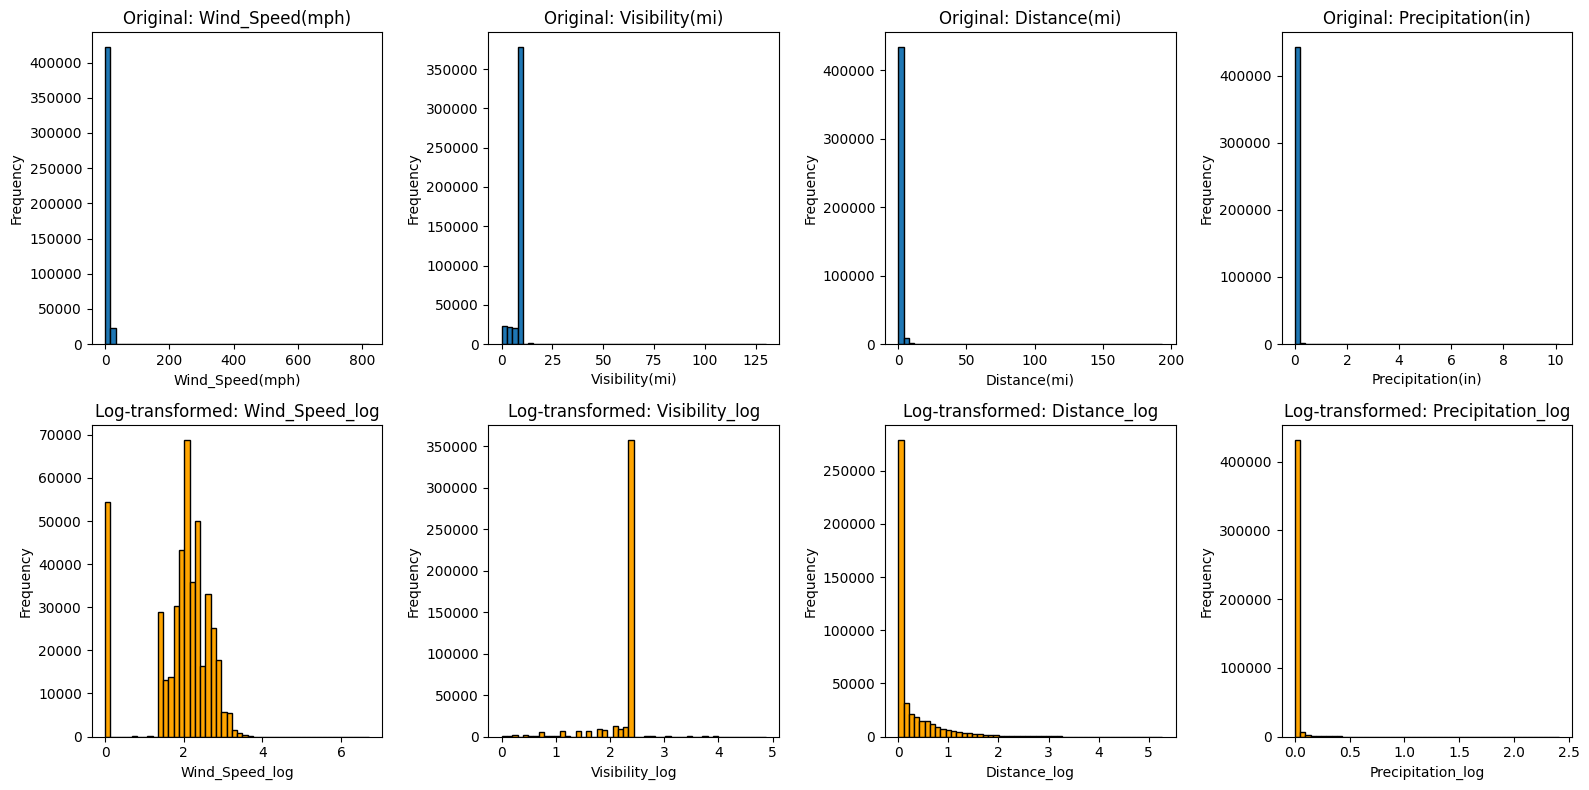


Dataset shape after transformations: (445073, 40)


In [20]:
print("\n" + "="*80)
print("STEP 3: LOG TRANSFORMATIONS")
print("="*80)

# Features with high skewness (from EDA)
skewed_features = ['Wind_Speed(mph)', 'Visibility(mi)', 'Distance(mi)', 'Precipitation(in)']

# Apply log1p transformation (log(1 + x) to handle zeros)
for feature in skewed_features:
    if feature in df_features.columns:
        new_feature_name = f'{feature.split("(")[0]}_log'
        df_features[new_feature_name] = np.log1p(df_features[feature])
        print(f"Created: {new_feature_name}")

# Compare distributions before/after (optional visualization)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, feature in enumerate(skewed_features):
    if feature in df_features.columns:
        # Original
        axes[0, i].hist(df_features[feature], bins=50, edgecolor='black')
        axes[0, i].set_title(f'Original: {feature}')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Frequency')
        
        # Log-transformed
        log_feature = f'{feature.split("(")[0]}_log'
        axes[1, i].hist(df_features[log_feature], bins=50, edgecolor='black', color='orange')
        axes[1, i].set_title(f'Log-transformed: {log_feature}')
        axes[1, i].set_xlabel(log_feature)
        axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('results/figures/bivariate/07_log_transformations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDataset shape after transformations: {df_features.shape}")


In [22]:
df_features = df_features.drop(columns=skewed_features)
print(f"Dataset shape after dropping original skewed features: {df_features.shape}")

Dataset shape after dropping original skewed features: (445073, 36)


##  SCALING NUMERIC COLUMNS

In [25]:
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("STEP 6: FEATURE SCALING")
print("="*80)

# Identify numerical columns (exclude binary 0/1 features)
binary_columns = [col for col in X_train.columns if X_train[col].nunique() == 2 and set(X_train[col].unique()).issubset({0, 1})]
numerical_columns = [col for col in X_train.columns if col not in binary_columns]

print(f"Binary features (will NOT scale): {len(binary_columns)}")
print(f"Numerical features (will scale): {len(numerical_columns)}")

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Verify scaling
print("\nBefore scaling (sample numerical features):")
print(X_train[numerical_columns[:5]].describe())

print("\nAfter scaling (same features):")
print(X_train_scaled[numerical_columns[:5]].describe())

print("\n✓ Scaling complete - mean ≈ 0, std ≈ 1")


STEP 6: FEATURE SCALING
Binary features (will NOT scale): 64
Numerical features (will scale): 14

Before scaling (sample numerical features):
           Start_Lat      Start_Lng   Distance(mi)  Temperature(F)  \
count  356058.000000  356058.000000  356058.000000   356058.000000   
mean       36.218415     -94.790419       0.513642       61.703692   
std         5.068229      17.347998       1.724109       18.854101   
min        24.562117    -124.495743       0.000000      -77.800000   
25%        33.412899    -117.226197       0.000000       49.000000   
50%        35.802725     -87.907537       0.010000       64.000000   
75%        40.104579     -80.415251       0.385000       76.000000   
max        48.999569     -67.484130     193.479996      196.000000   

         Humidity(%)  
count  356058.000000  
mean       65.033357  
std        22.727294  
min         1.000000  
25%        49.000000  
50%        67.000000  
75%        84.000000  
max       100.000000  

After scaling (sam

## HANDLING CLASS IMBALANCE WITH SMOTE

In [26]:
from imblearn.over_sampling import SMOTE

print("\n" + "="*80)
print("STEP 7: CLASS IMBALANCE HANDLING (SMOTE)")
print("="*80)

# Check class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().sort_index())
print("\nPercentages:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

# Apply SMOTE (only on training data!)
# Strategy: 'not majority' balances all minority classes to match majority
smote = SMOTE(random_state=42, sampling_strategy='not majority')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())
print("\nPercentages:")
print(pd.Series(y_train_balanced).value_counts(normalize=True).sort_index() * 100)

print(f"\nTraining set size increased: {len(y_train)} → {len(y_train_balanced)}")
print(f"Increase: {len(y_train_balanced) - len(y_train):,} synthetic samples")

print("\n✓ SMOTE complete - minority classes balanced")


STEP 7: CLASS IMBALANCE HANDLING (SMOTE)
Class distribution BEFORE SMOTE:
Severity
1      3381
2    276702
3     66729
4      9246
Name: count, dtype: int64

Percentages:
Severity
1     0.949564
2    77.712620
3    18.741048
4     2.596768
Name: proportion, dtype: float64

Class distribution AFTER SMOTE:
Severity
1    276702
2    276702
3    276702
4    276702
Name: count, dtype: int64

Percentages:
Severity
1    25.0
2    25.0
3    25.0
4    25.0
Name: proportion, dtype: float64

Training set size increased: 356058 → 1106808
Increase: 750,750 synthetic samples

✓ SMOTE complete - minority classes balanced


In [27]:
import os
import joblib

# Create folder
os.makedirs("test_train", exist_ok=True)

# Save train/test data
joblib.dump(X_train_scaled, "test_train/X_train_scaled.pkl")
joblib.dump(X_test_scaled, "test_train/X_test_scaled.pkl")
joblib.dump(y_train, "test_train/y_train.pkl")
joblib.dump(y_test, "test_train/y_test.pkl")

# Save SMOTE versions too, if you want to compare later
joblib.dump(X_train_balanced, "test_train/X_train_balanced.pkl")
joblib.dump(y_train_balanced, "test_train/y_train_balanced.pkl")

# Optional but useful
joblib.dump(X_train_scaled.columns.tolist(), "test_train/feature_columns.pkl")

print("Saved all train/test files in 'test_train'")

Saved all train/test files in 'test_train'
